In [1]:
from typing import TypedDict, Literal

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    target_currency : Literal["EUR", "INR"]
    total: float

In [5]:
# Define Nodes
# Which is nothing but simple python functions
def calc_total(state:PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state:PortfolioState) -> PortfolioState :
    state['total'] = state['total_usd'] * 85
    return state

def convert_to_eur(state:PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.86
    return state

def chose_conversion(state:PortfolioState) -> str:
    return state['target_currency']

In [6]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node('calculate_total_node', calc_total)
builder.add_node('convert_to_inr_node', convert_to_inr)
builder.add_node('convert_to_eur_node', convert_to_eur)

builder.add_edge(START, 'calculate_total_node')
builder.add_conditional_edges(
    'calculate_total_node',
    chose_conversion,
    {
        "INR" : "convert_to_inr_node",
        "EUR" : "convert_to_eur_node"
    }
)

# This works
# builder.add_edge('convert_to_inr_node', END)
# builder.add_edge('convert_to_eur_node', END)

# Or either this works as well
builder.add_edge(['convert_to_inr_node', 'convert_to_eur_node'], END)

graph = builder.compile()

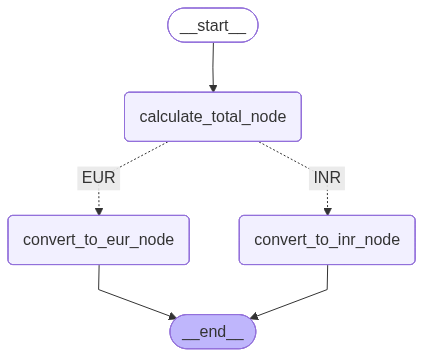

In [7]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from typing import cast
graph.invoke(cast(PortfolioState, { "amount_usd": 1000, "target_currency": "INR" }))

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'INR',
 'total': 91800.0}

In [10]:
from typing import cast
graph.invoke(cast(PortfolioState, { "amount_usd": 1000, "target_currency": "EUR" }))

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'EUR',
 'total': 928.8}